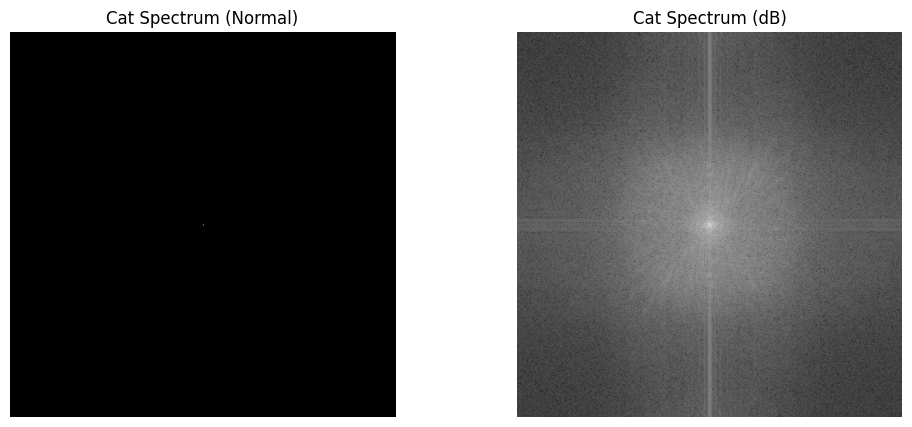

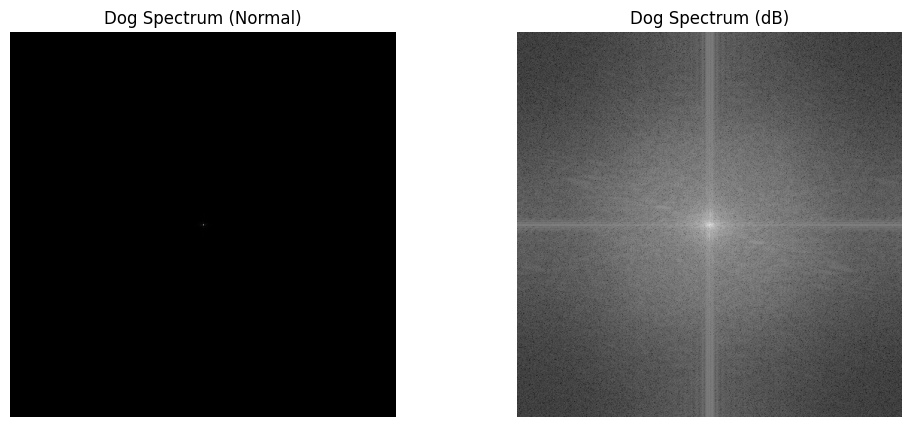

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Load grayscale images and resize to same shape for consistency
img1 = Image.open('cat_gray.jpg').convert('L').resize((512, 512))
img2 = Image.open('dog_gray.jpg').convert('L').resize((512, 512))
img1orig = img1
#Convert to NumPy Arrays
img1 = np.array(img1)
img2 = np.array(img2)


def show_magnitude_spectrum(img, title_prefix=""):
    # Compute 2D DFT and magnitude
    dft = np.fft.fft2(img)
    dft_shifted = np.fft.fftshift(dft)
    magnitude = np.abs(dft_shifted)
    magnitude_db = 20 * np.log1p(magnitude)  # log(1 + mag)

    # Plot
    plt.figure(figsize=(12,5))
    plt.subplot(1, 2, 1)
    plt.imshow(magnitude, cmap='gray')
    plt.title(f"{title_prefix} Spectrum (Normal)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_db, cmap='gray')
    plt.title(f"{title_prefix} Spectrum (dB)")
    plt.axis('off')
    plt.show()

    return dft_shifted

# Show magnitude spectra
dft1 = show_magnitude_spectrum(img1, "Cat")
dft2 = show_magnitude_spectrum(img2, "Dog")



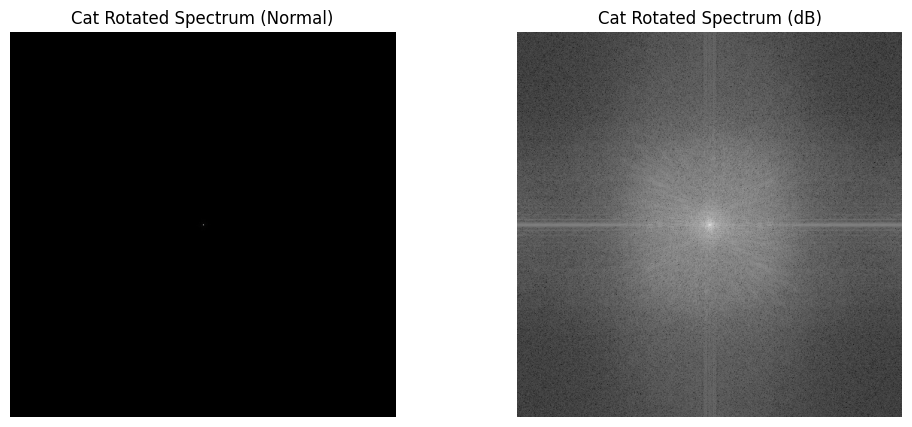

In [2]:
# Rotate image by 90 degrees anti-clockwise
img1_rotated = np.rot90(img1,k=1)
dft1_rot = show_magnitude_spectrum(img1_rotated, "Cat Rotated")

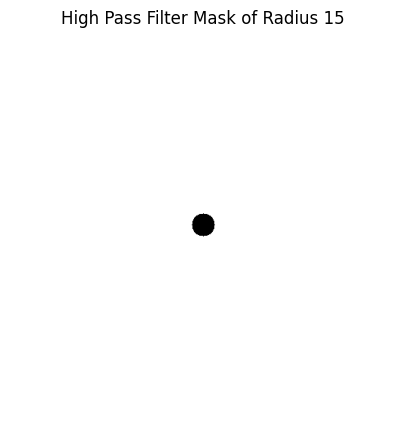

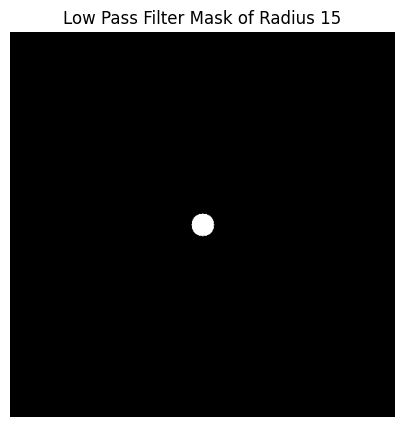

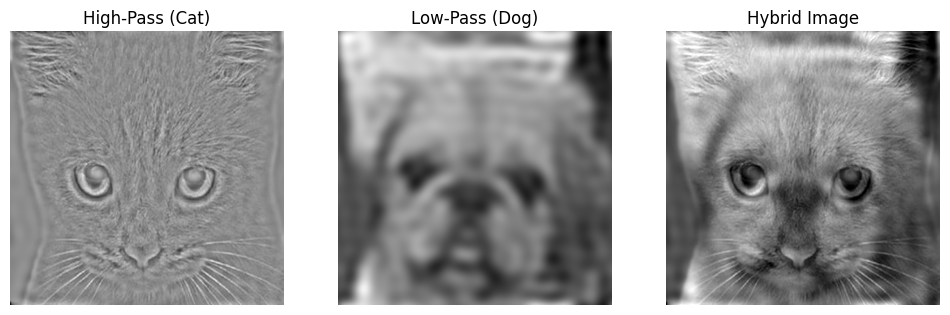

In [3]:
# Low-pass filter for img2
def low_pass_filter(img, radius=15):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    rows, cols = img.shape
    crow, ccol = rows//2 , cols//2
    mask = np.zeros_like(img)
    cv2.circle(mask, (ccol, crow), radius, 1, thickness=-1)

    filtered = fshift * mask

    plt.figure(figsize=(12,5))
    plt.imshow(mask, cmap='gray')
    plt.title("Low Pass Filter Mask of Radius 15")
    plt.axis('off')
    return np.real(np.fft.ifft2(np.fft.ifftshift(filtered)))

# High-pass filter for img1
def high_pass_filter(img, radius=15):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    rows, cols = img.shape
    crow, ccol = rows//2 , cols//2
    mask = np.ones_like(img)
    cv2.circle(mask, (ccol, crow), radius, 0, thickness=-1)

    filtered = fshift * mask

    plt.figure(figsize=(12,5))
    plt.subplot(1, 2, 1)
    plt.imshow(mask, cmap='gray')
    plt.title("High Pass Filter Mask of Radius 15")
    plt.axis('off')
    return np.real(np.fft.ifft2(np.fft.ifftshift(filtered)))

# Apply frequency filters
img1_high = high_pass_filter(img1)
img2_low = low_pass_filter(img2)

# Combine images
hybrid = img1_high + img2_low
hybrid = np.clip(hybrid, 0, 255).astype(np.uint8)

# Show hybrid result
plt.figure(figsize=(12,4))
plt.subplot(1,3,1), plt.imshow(img1_high, cmap='gray'), plt.title("High-Pass (Cat)"), plt.axis('off')
plt.subplot(1,3,2), plt.imshow(img2_low, cmap='gray'), plt.title("Low-Pass (Dog)"), plt.axis('off')
plt.subplot(1,3,3), plt.imshow(hybrid, cmap='gray'), plt.title("Hybrid Image"), plt.axis('off')
plt.show()